In [14]:
library(tidyverse)
library(GGally)
library(car)

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [3]:
players_data <- read_csv("players.csv")
head(players_data)

Rows: 1248 Columns: 13
── Column specification ───────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): team_country, position
dbl (11): age, minutes, goals, assists, cards_yellow, shots, shots_on_target...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


team_country,position,age,minutes,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Algeria,DF,26,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Algeria,FW,23,19,0,0,0,0,0,0,1,0,0
Algeria,FW,26,251,1,0,0,3,2,1,0,0,1
Algeria,MF,24,98,0,0,0,2,0,0,0,1,0
Algeria,DF,34,360,0,0,0,0,0,0,0,4,3
Algeria,MF,23,360,0,0,1,9,3,3,1,3,5


In [7]:
goals_by_country <- players_data %>%
    group_by(team_country) %>%
    summarise(goals_per_country = sum(goals, na.rm=TRUE)) %>%
    arrange(desc(goals_per_country))

head(goals_by_country)

team_country,goals_per_country
<chr>,<dbl>
England,20
France,20
Argentina,18
Belgium,13
Spain,13
Norway,12


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


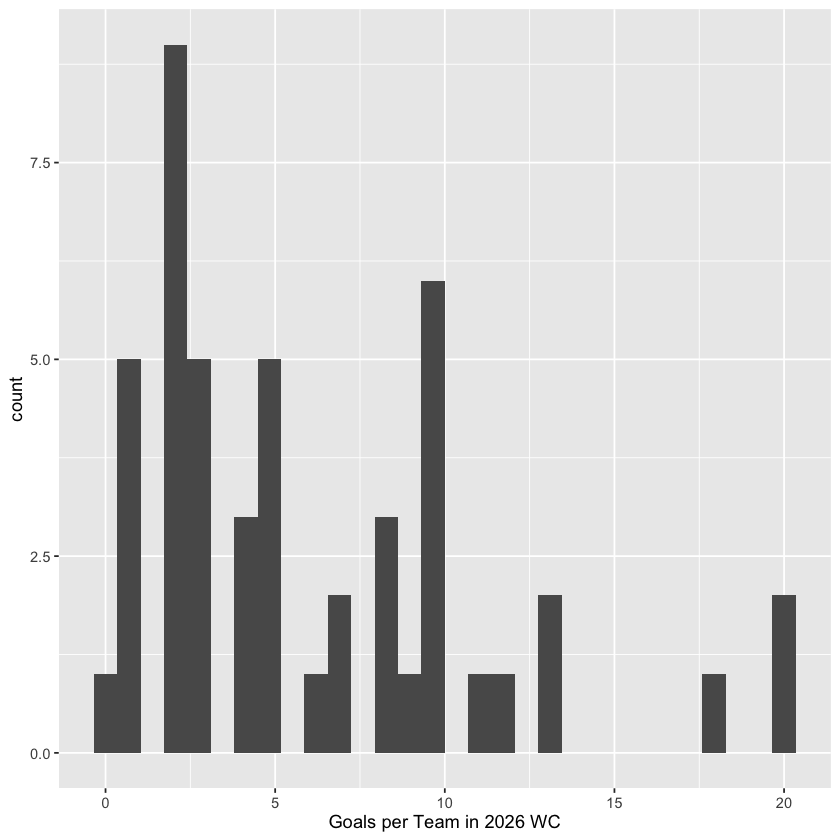

In [13]:
ggplot(goals_by_country, aes(x=goals_per_country)) + 
    geom_histogram() + 
    labs(x = "Goals per Team in 2026 WC")

In [17]:
lm_goals <- lm(goals ~ minutes + assists + shots + shots_on_target + fouls + cards_yellow + offsides + interceptions + tackles_won + age, data = players_data)
vif(lm_goals)

minutes         assists           shots shots_on_target           fouls 
       2.308520        1.287801        5.454901        4.875135        1.947164 
   cards_yellow        offsides   interceptions     tackles_won             age 
       1.247894        1.463325        1.806283        1.842904        1.060636

In [20]:
lm_goals_no_shots <- lm(goals ~ minutes + assists + shots_on_target + fouls + cards_yellow + offsides + interceptions + tackles_won + age, data = players_data)
vif(lm_goals_no_shots)

minutes         assists shots_on_target           fouls    cards_yellow 
       2.259230        1.247562        1.755651        1.926580        1.247829 
       offsides   interceptions     tackles_won             age 
       1.446294        1.802322        1.835281        1.057355

In [21]:
lm_goals_no_shots_no_min <- lm(goals ~ assists + shots_on_target + fouls + cards_yellow + offsides + interceptions + tackles_won + age, data = players_data)
vif(lm_goals_no_shots_no_min)

assists shots_on_target           fouls    cards_yellow        offsides 
       1.219959        1.635843        1.838940        1.246385        1.442835 
  interceptions     tackles_won             age 
       1.593665        1.728505        1.023516

In [24]:
players_data %>%
    filter(!is.na(goals)) %>%
    count(scored=goals > 0) %>%
    mutate(pct=round(n/sum(n) * 100, 1))

scored,n,pct
<lgl>,<int>,<dbl>
FALSE,860,82.8
TRUE,179,17.2


In [28]:
scorers <- players_data %>% filter(goals>0)
non_scorers <-players_data %>% filter(goals==0)

nrow(scorers)
nrow(non_scorers)

head(scorers)
head(non_scorers)

[1] 179

[1] 860

team_country,position,age,minutes,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Algeria,FW,26,251,1,0,0,3,2,1,0,0,1
Algeria,FW,26,45,1,0,0,2,2,0,0,0,1
Algeria,DF,24,331,1,0,0,3,1,4,0,1,3
Algeria,MF,35,262,2,1,0,6,3,1,1,1,2
Argentina,MF,27,750,1,1,1,13,4,9,0,9,12
Argentina,DF,28,608,1,0,2,3,1,9,0,11,10


team_country,position,age,minutes,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Algeria,FW,23,19,0,0,0,0,0,0,1,0,0
Algeria,MF,24,98,0,0,0,2,0,0,0,1,0
Algeria,DF,34,360,0,0,0,0,0,0,0,4,3
Algeria,MF,23,360,0,0,1,9,3,3,1,3,5
Algeria,"FW,MF",23,1,0,0,0,0,0,0,0,0,0
Algeria,MF,26,128,0,0,1,0,0,4,0,2,1


scored,n,mean_shots,mean_shots_on_target,mean_minutes,mean_assists,mean_offsides,mean_age,mean_interceptions,mean_tackles_won,mean_fouls
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,860,1.580233,0.3755814,184.5965,0.1523256,0.2395349,27.57442,1.600000,1.813953,2.053488
Scored,179,6.810056,3.1452514,294.1732,0.5195531,0.9050279,26.93296,2.027933,2.597765,3.608939


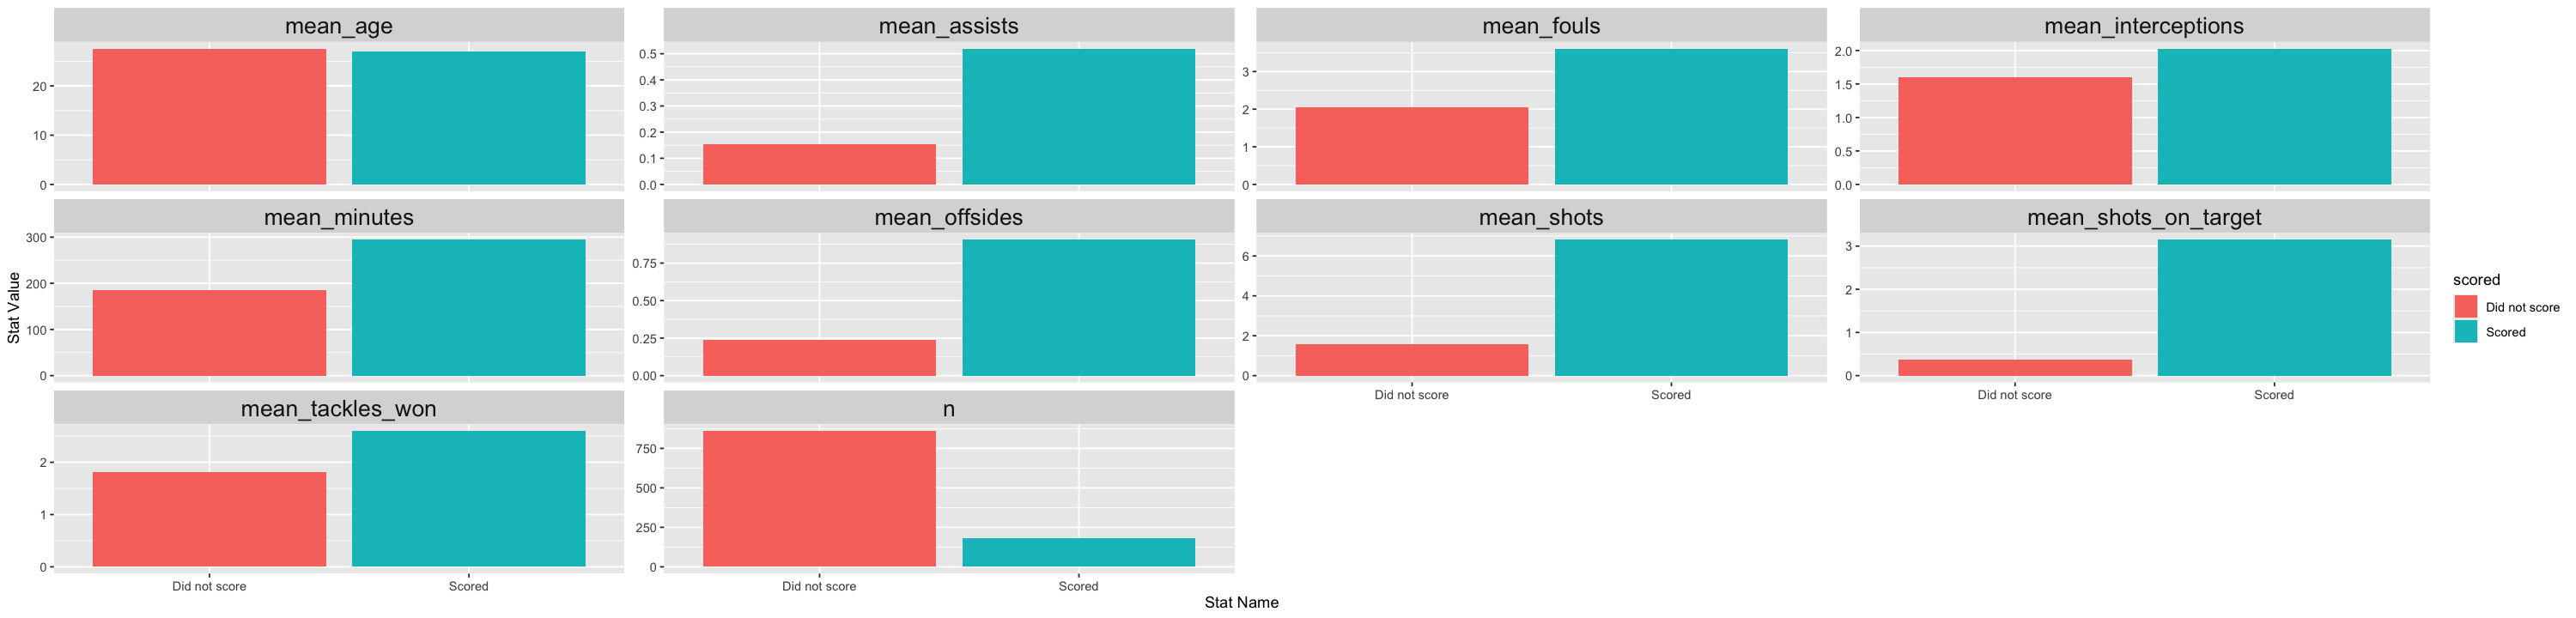

In [93]:
# Mean of numerical attributes for players that scored vs. didn't score

scored_vs_did_not_score <- players_data %>% 
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots=mean(shots),
        mean_shots_on_target=mean(shots_on_target),
        mean_minutes=mean(minutes),
        mean_assists=mean(assists),
        mean_offsides=mean(offsides),
        mean_age=mean(age),
        mean_interceptions=mean(interceptions),
        mean_tackles_won=mean(tackles_won),
        mean_fouls=mean(fouls)
    )

scored_vs_did_not_score

ggplot(scored_vs_did_not_score %>% pivot_longer(-scored, names_to = "stat", values_to="per_min"), aes(x=scored, y=per_min, fill=scored)) +
    geom_col(position = "dodge") +
    # coord_flip() + 
    facet_wrap(~ stat, scales = "free_y") +
    labs(x="Stat Name", y="Stat Value") +
    theme(strip.text = element_text(size=16))

In [79]:
# Scored vs. did not score for forwards

players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="FW") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots=mean(shots),
        mean_shots_on_target=mean(shots_on_target),
        mean_minutes=mean(minutes),
        mean_assists=mean(assists),
        mean_offsides=mean(offsides),
        mean_age=mean(age),
        mean_interceptions=mean(interceptions),
        mean_tackles_won=mean(tackles_won),
        mean_fouls=mean(fouls),
        mean_cards_yellow=mean(cards_yellow)
    )

# Scored vs. did not score for midfielders
players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="MF") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots=mean(shots),
        mean_shots_on_target=mean(shots_on_target),
        mean_minutes=mean(minutes),
        mean_assists=mean(assists),
        mean_offsides=mean(offsides),
        mean_age=mean(age),
        mean_interceptions=mean(interceptions),
        mean_tackles_won=mean(tackles_won),
        mean_fouls=mean(fouls),
        mean_cards_yellow=mean(cards_yellow)
    )

# Scored vs. did not score for defenders
players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="DF") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots=mean(shots),
        mean_shots_on_target=mean(shots_on_target),
        mean_minutes=mean(minutes),
        mean_assists=mean(assists),
        mean_offsides=mean(offsides),
        mean_age=mean(age),
        mean_interceptions=mean(interceptions),
        mean_tackles_won=mean(tackles_won),
        mean_fouls=mean(fouls),
        mean_cards_yellow=mean(cards_yellow)
    )

scored,n,mean_shots,mean_shots_on_target,mean_minutes,mean_assists,mean_offsides,mean_age,mean_interceptions,mean_tackles_won,mean_fouls,mean_cards_yellow
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,175,1.680000,0.4514286,87.96,0.1028571,0.4857143,27.63429,0.2914286,0.680000,1.360000,0.09142857
Scored,61,9.213115,4.5245902,286.00,0.7377049,1.6721311,27.85246,0.8852459,1.360656,3.737705,0.31147541


scored,n,mean_shots,mean_shots_on_target,mean_minutes,mean_assists,mean_offsides,mean_age,mean_interceptions,mean_tackles_won,mean_fouls,mean_cards_yellow
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,302,2.423841,0.5529801,186.5000,0.2582781,0.2251656,26.41722,1.778146,2.274834,2.619205,0.2880795
Scored,90,6.311111,2.7000000,289.3111,0.4555556,0.6000000,26.22222,2.311111,3.066667,3.466667,0.4333333


scored,n,mean_shots,mean_shots_on_target,mean_minutes,mean_assists,mean_offsides,mean_age,mean_interceptions,mean_tackles_won,mean_fouls,mean_cards_yellow
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,321,1.037383,0.2398754,211.1433,0.1090343,0.1651090,27.95639,2.445483,2.342679,2.286604,0.2866044
Scored,28,3.178571,1.5714286,327.6071,0.2500000,0.2142857,27.21429,3.607143,3.785714,3.785714,0.5000000


In [46]:
# Scored vs. did not score for forwards (per minute stats)
players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="FW") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots_per_min=mean(shots/minutes),
        mean_shots_on_target_per_min=mean(shots_on_target/minutes),
        mean_assists_per_min=mean(assists/minutes),
        mean_offsides_per_min=mean(offsides/minutes),
        mean_interceptions_per_min=mean(interceptions/minutes),
        mean_tackles_won_per_min=mean(tackles_won/minutes),
        mean_fouls_per_min=mean(fouls/minutes),
        mean_cards_yellow_per_min=mean(cards_yellow/minutes)
    )

# Scored vs. did not score for midfielders (per minute stats)
players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="MF") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots_per_min=mean(shots/minutes),
        mean_shots_on_target_per_min=mean(shots_on_target/minutes),
        mean_assists_per_min=mean(assists/minutes),
        mean_offsides_per_min=mean(offsides/minutes),
        mean_interceptions_per_min=mean(interceptions/minutes),
        mean_tackles_won_per_min=mean(tackles_won/minutes),
        mean_fouls_per_min=mean(fouls/minutes),
        mean_cards_yellow_per_min=mean(cards_yellow/minutes)
    )

# Scored vs. did not score for defenders (per minute stats)
players_data %>% 
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos=="DF") %>%
    filter(!is.na(goals)) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(scored) %>%
    summarise(
        n=n(),
        mean_shots_per_min=mean(shots/minutes),
        mean_shots_on_target_per_min=mean(shots_on_target/minutes),
        mean_assists_per_min=mean(assists/minutes),
        mean_offsides_per_min=mean(offsides/minutes),
        mean_interceptions_per_min=mean(interceptions/minutes),
        mean_tackles_won_per_min=mean(tackles_won/minutes),
        mean_fouls_per_min=mean(fouls/minutes),
        mean_cards_yellow_per_min=mean(cards_yellow/minutes)        
    )

scored,n,mean_shots_per_min,mean_shots_on_target_per_min,mean_assists_per_min,mean_offsides_per_min,mean_interceptions_per_min,mean_tackles_won_per_min,mean_fouls_per_min,mean_cards_yellow_per_min
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,175,0.02410366,0.005134514,0.001074531,0.007362939,0.002607404,0.016400054,0.02482652,0.004391037
Scored,61,0.03430472,0.017014430,0.002517069,0.005880261,0.003146934,0.004673205,0.01481493,0.001636117


scored,n,mean_shots_per_min,mean_shots_on_target_per_min,mean_assists_per_min,mean_offsides_per_min,mean_interceptions_per_min,mean_tackles_won_per_min,mean_fouls_per_min,mean_cards_yellow_per_min
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,302,0.01422048,0.003149014,0.001237062,0.001232718,0.016451105,0.01571293,0.01486481,0.002508463
Scored,90,0.02443912,0.011118986,0.001515715,0.002179441,0.008875815,0.01073444,0.01246212,0.001599814


scored,n,mean_shots_per_min,mean_shots_on_target_per_min,mean_assists_per_min,mean_offsides_per_min,mean_interceptions_per_min,mean_tackles_won_per_min,mean_fouls_per_min,mean_cards_yellow_per_min
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Did not score,321,0.005502686,0.001170838,0.0005279442,0.0015957870,0.01426832,0.01289172,0.01330762,0.001685592
Scored,28,0.022321522,0.017579279,0.0006285371,0.0006930399,0.01078141,0.01107463,0.01096670,0.001204983


In [48]:
options(repr.plot.width = 25, repr.plot.height = 6)

per_position_per_minute_summary <- players_data %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(!is.na(goals), pos %in% c("DF", "MF", "FW")) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(pos, scored) %>%
    summarise(
        mean_shots_per_min=mean(shots/minutes),
        mean_shots_on_target_per_min=mean(shots_on_target/minutes),
        mean_assists_per_min=mean(assists/minutes),
        mean_offsides_per_min=mean(offsides/minutes),
        mean_interceptions_per_min=mean(interceptions/minutes),
        mean_tackles_won_per_min=mean(tackles_won/minutes),
        mean_fouls_per_min=mean(fouls/minutes),
        mean_cards_yellow_per_min=mean(cards_yellow/minutes),
        .groups="drop"
    ) %>%
    pivot_longer(-c(pos, scored), names_to = "stat", values_to="per_min")

ggplot(per_position_per_minute_summary, aes(x=stat, y=per_min, fill=scored)) +
    geom_col(position = "dodge") +
    facet_wrap(~ pos) +
    coord_flip() + 
    labs(x="Stat Name (mean per minute)", y="Stat Value (mean per minute)")

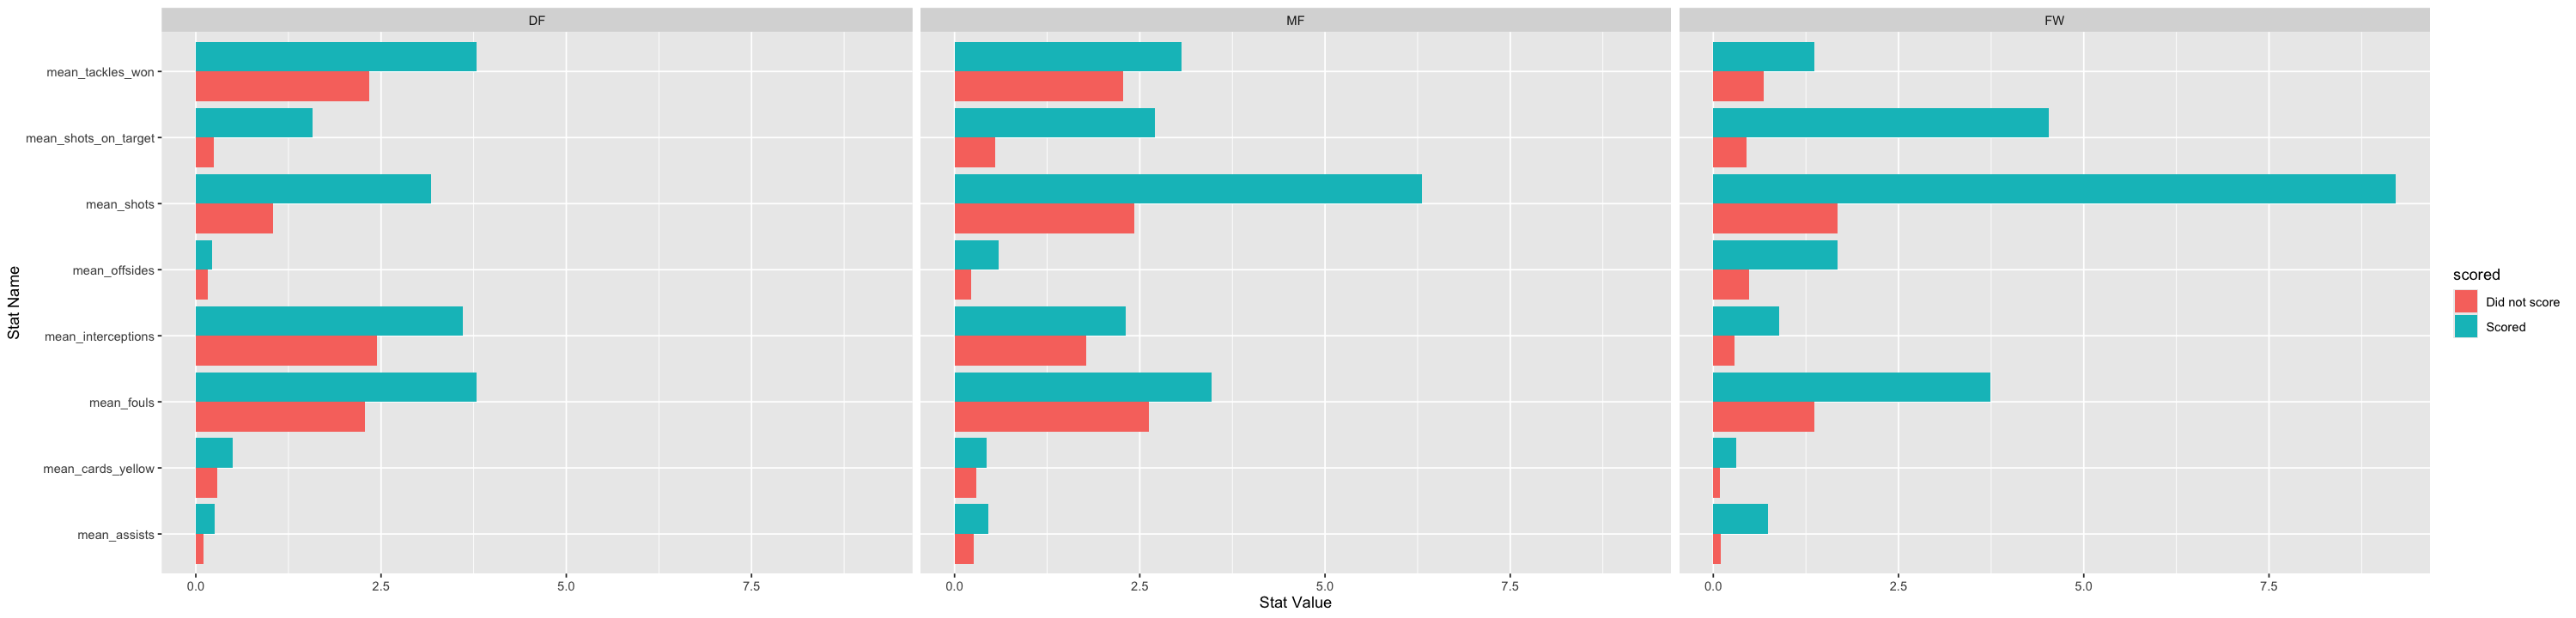

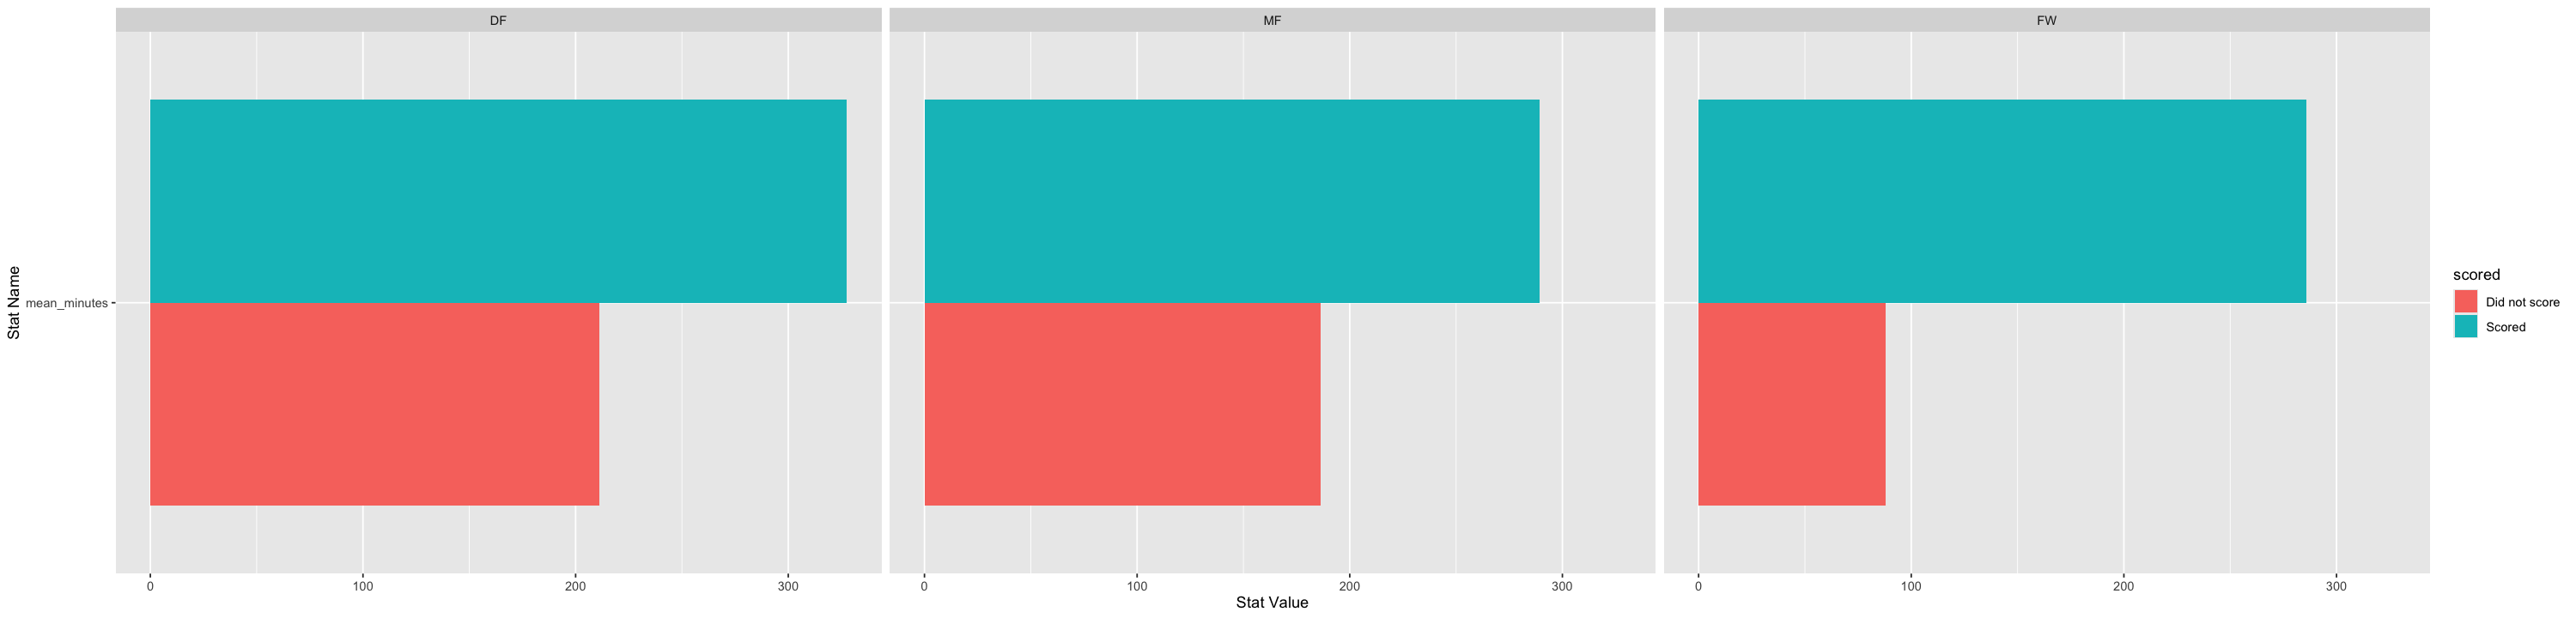

In [103]:
options(repr.plot.width = 25, repr.plot.height = 6)

per_position_summary <- players_data %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(!is.na(goals), pos %in% c("DF", "MF", "FW")) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(pos, scored) %>%
    summarise(
        mean_shots=mean(shots),
        mean_shots_on_target=mean(shots_on_target),
        mean_assists=mean(assists),
        mean_offsides=mean(offsides),
        mean_interceptions=mean(interceptions),
        mean_tackles_won=mean(tackles_won),
        mean_fouls=mean(fouls),
        mean_cards_yellow=mean(cards_yellow),
        .groups="drop"
    ) %>%
    pivot_longer(-c(pos, scored), names_to = "stat", values_to="per_min")

ggplot(per_position_summary, aes(x=stat, y=per_min, fill=scored)) +
    geom_col(position = "dodge") +
    facet_wrap(~ pos) +
    coord_flip() + 
    labs(x="Stat Name", y="Stat Value")

per_position_summary_min_played <- players_data %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(!is.na(goals), pos %in% c("DF", "MF", "FW")) %>%
    mutate(scored=if_else(goals > 0, "Scored", "Did not score")) %>%
    group_by(pos, scored) %>%
    summarise(
        mean_minutes=mean(minutes),
        .groups="drop"
    ) %>%
    pivot_longer(-c(pos, scored), names_to = "stat", values_to="per_min")

ggplot(per_position_summary_min_played, aes(x=stat, y=per_min, fill=scored)) +
    geom_col(position = "dodge") +
    facet_wrap(~ pos) +
    coord_flip() + 
    labs(x="Stat Name", y="Stat Value")

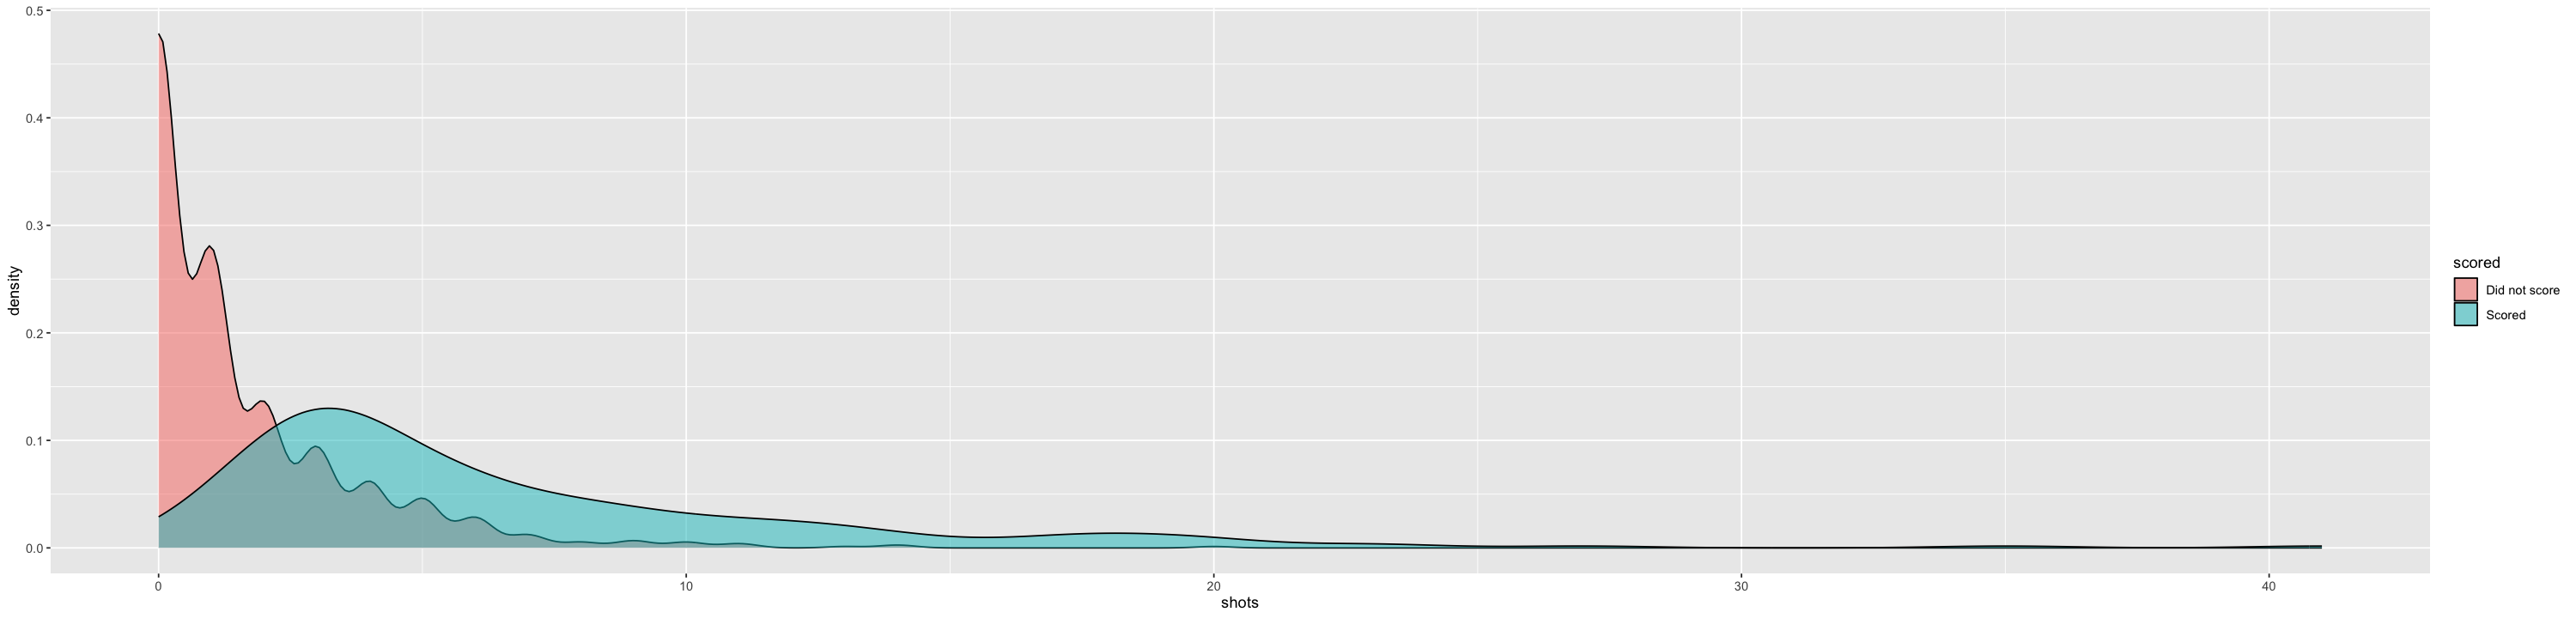

In [66]:
# Distribution between shot count for scorers vs. non-scorers

players_data %>%
    filter(!is.na(goals)) %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=shots, fill=scored)) + 
    geom_density(alpha=0.5)

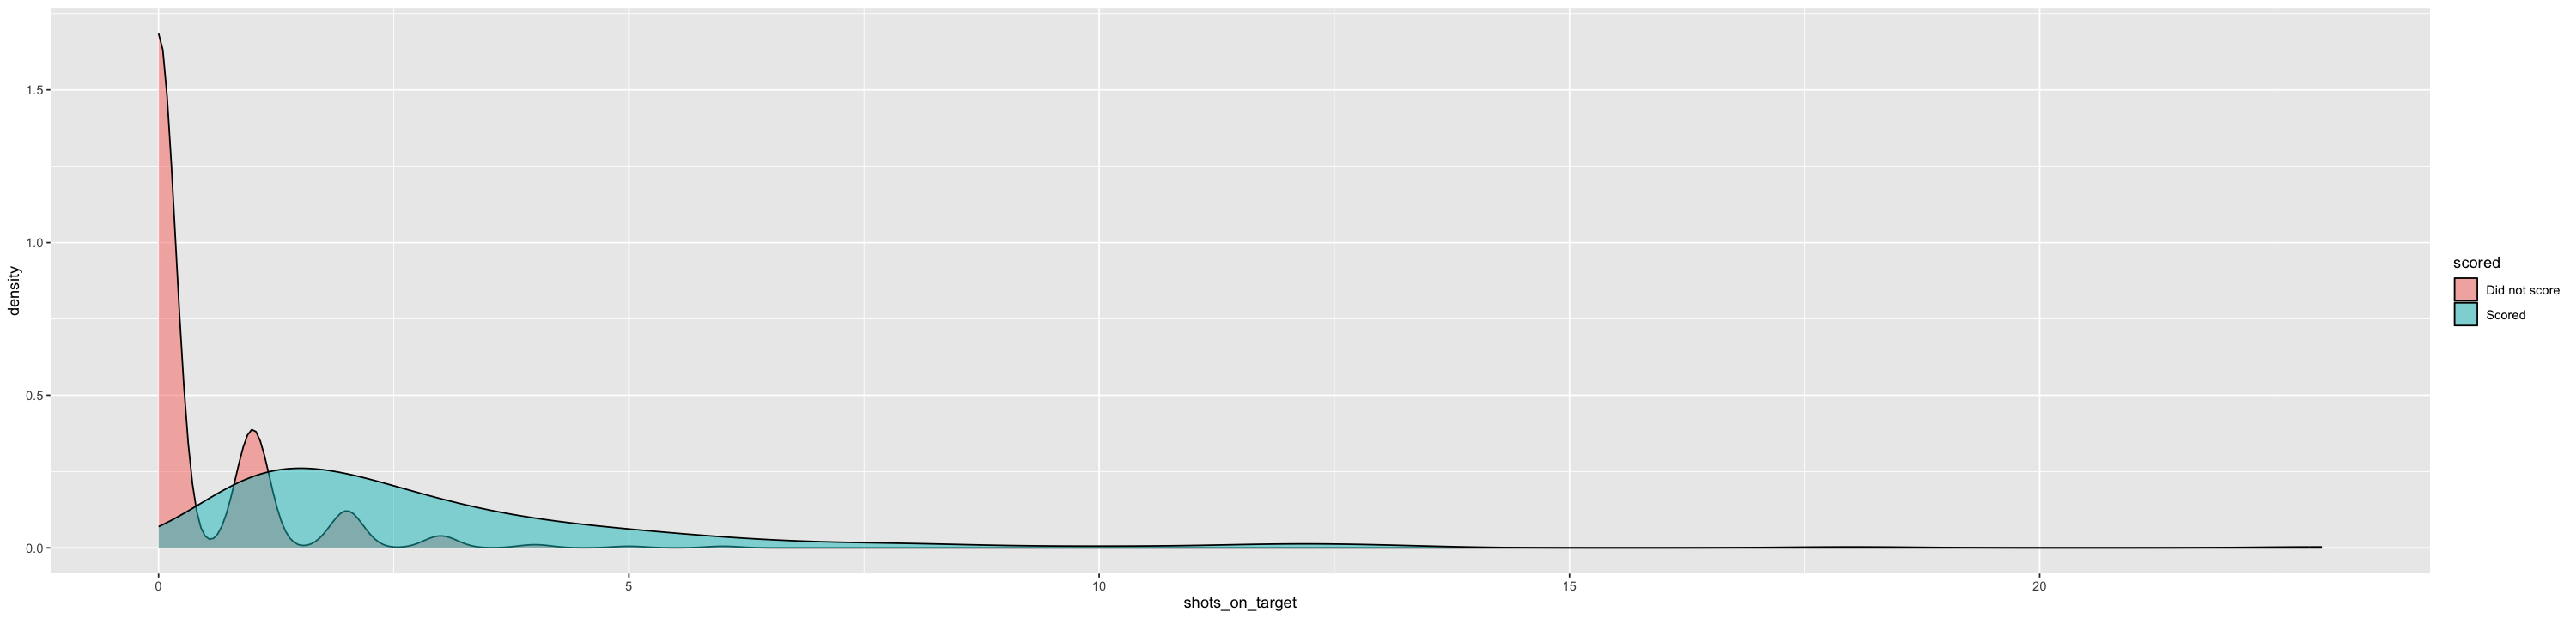

In [64]:
# Distribution between numer of shots on target for scorers vs. non-scorers

players_data %>%
    filter(!is.na(goals)) %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=shots_on_target, fill=scored)) + 
    geom_density(alpha=0.5)

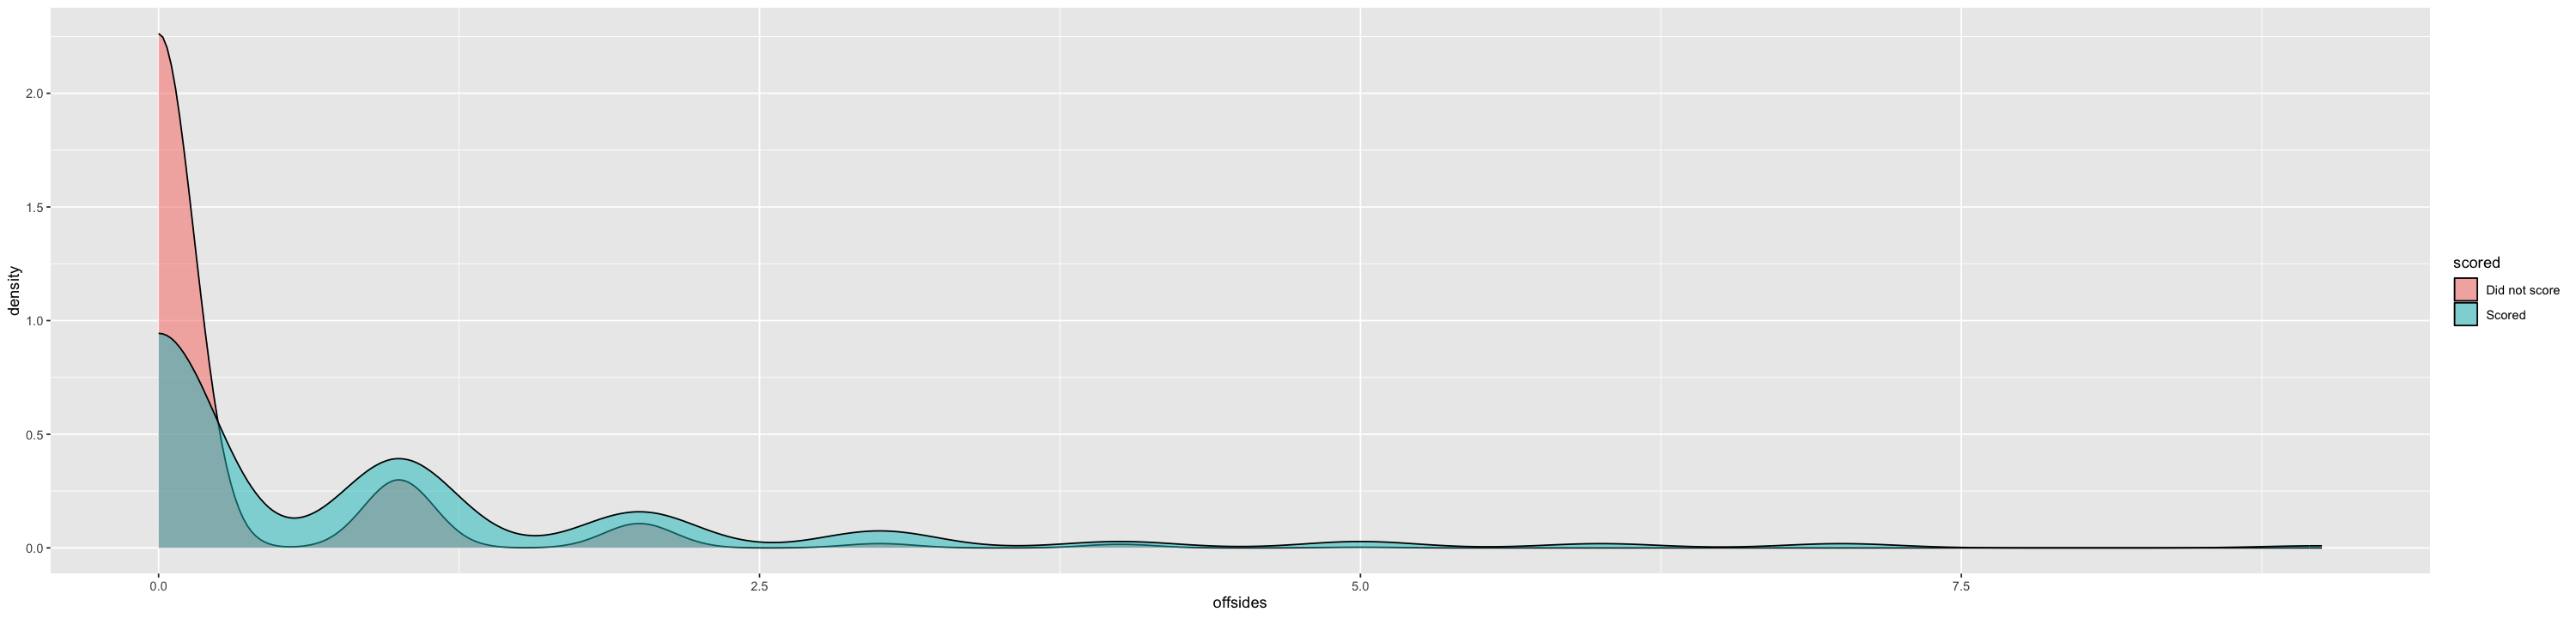

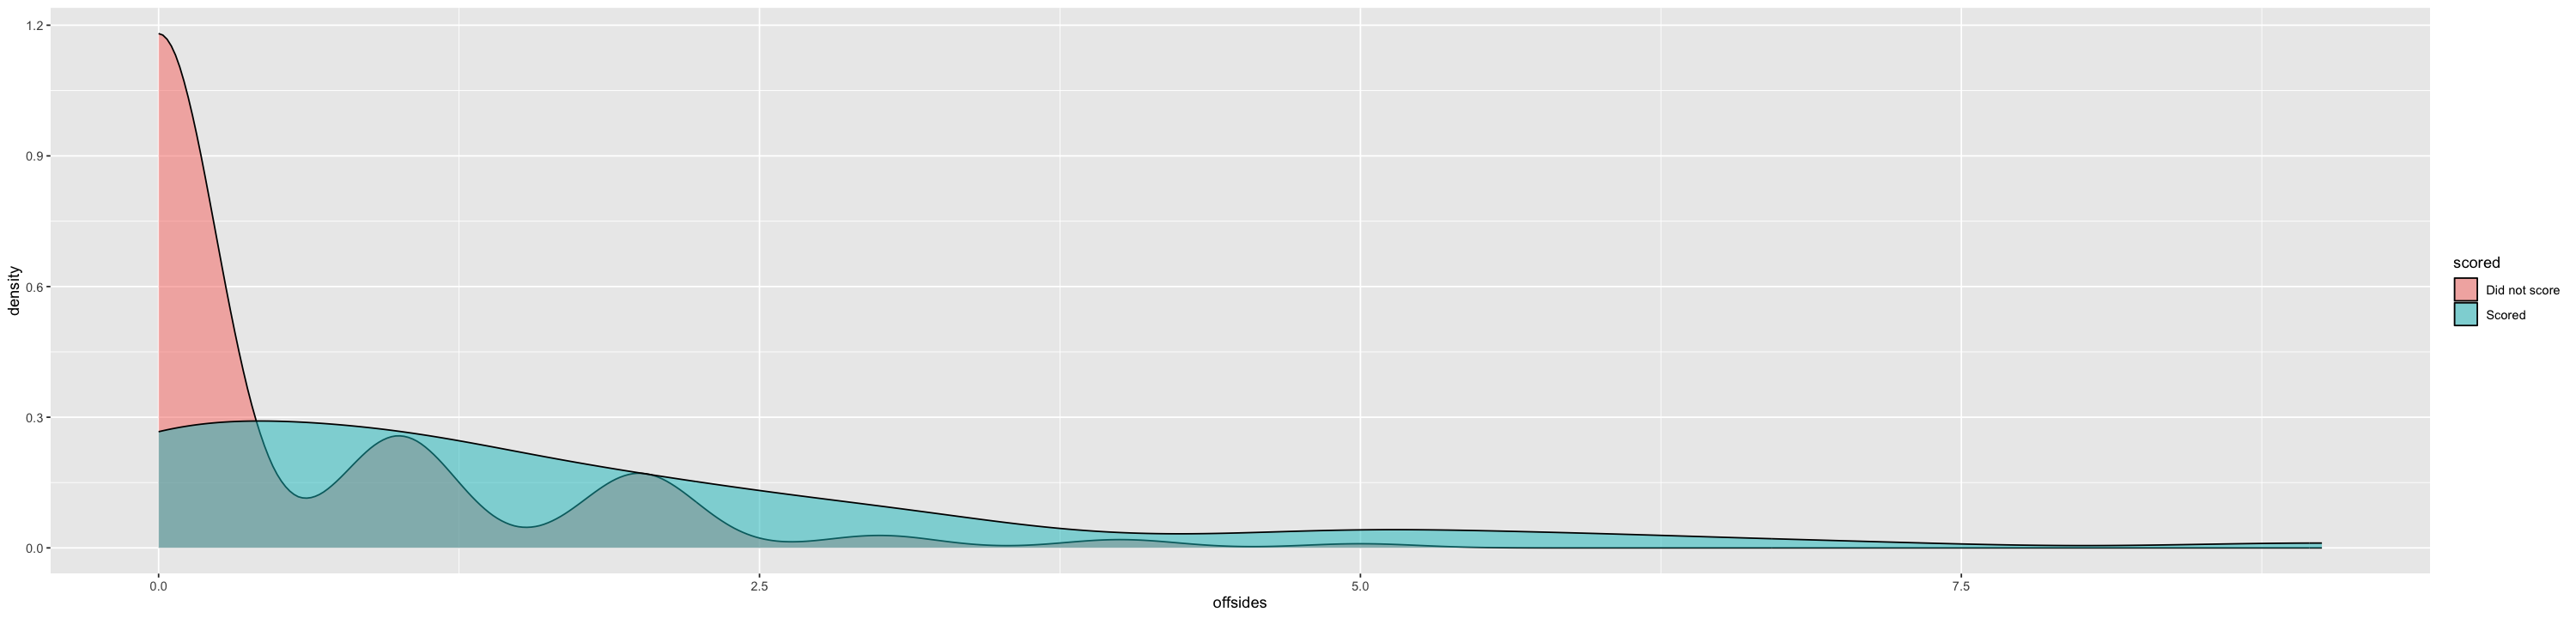

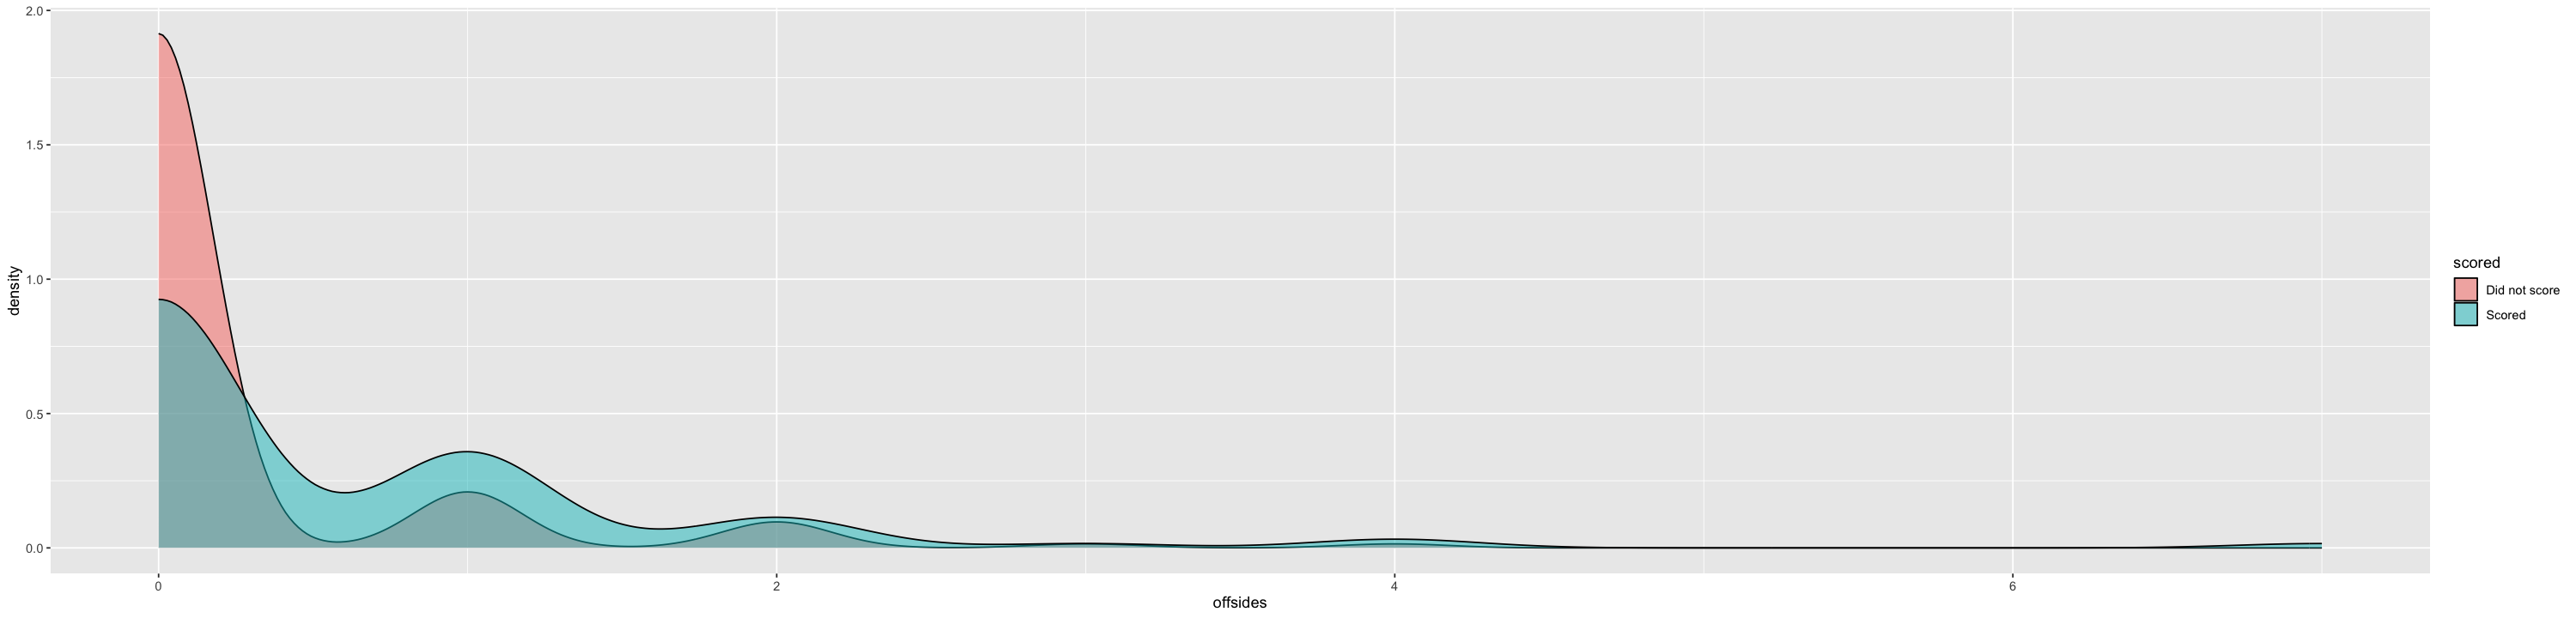

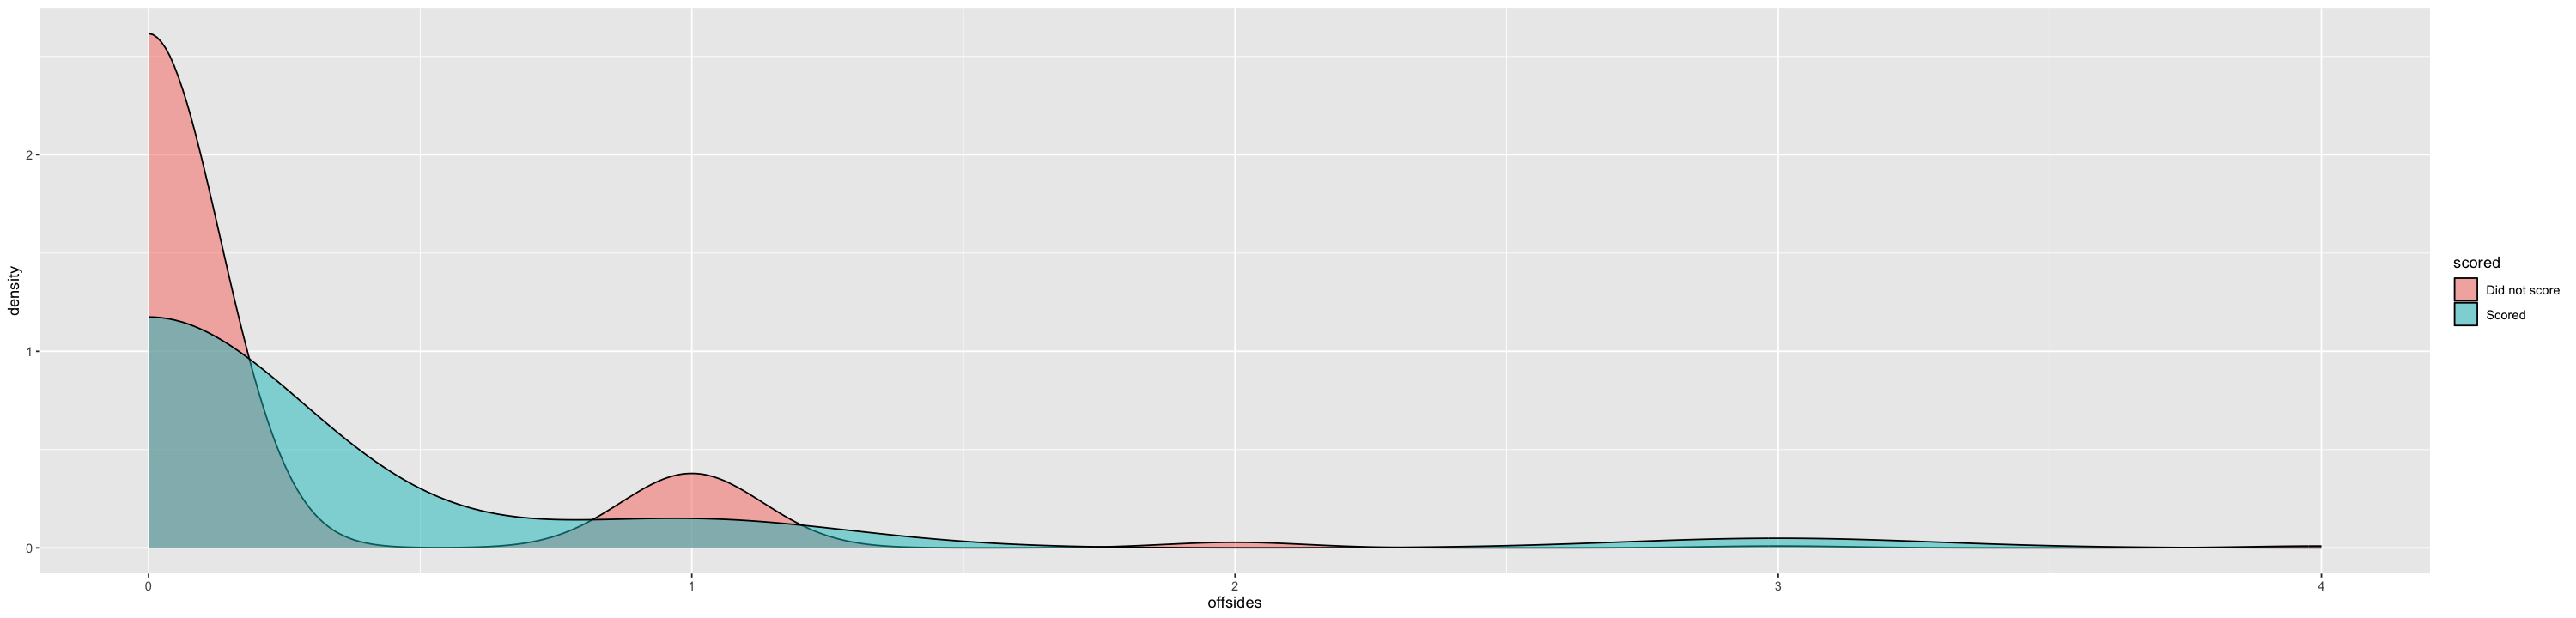

In [73]:
# Distribution between numer of offsides on target for scorers vs. non-scorers

players_data %>%
    filter(!is.na(goals)) %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=offsides, fill=scored)) + 
    geom_density(alpha=0.5)

# Distribution between numer of offsides on target for scorers vs. non-scorers (for forwards)
players_data %>%
    filter(!is.na(goals)) %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos == "FW") %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=offsides, fill=scored)) + 
    geom_density(alpha=0.5)

# Distribution between numer of offsides on target for scorers vs. non-scorers (for midfielders)
players_data %>%
    filter(!is.na(goals)) %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos == "MF") %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=offsides, fill=scored)) + 
    geom_density(alpha=0.5)

# Distribution between numer of offsides on target for scorers vs. non-scorers (for defenders)
players_data %>%
    filter(!is.na(goals)) %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    filter(pos == "DF") %>%
    mutate(scored = if_else(goals > 0, "Scored", "Did not score")) %>%
    ggplot(aes(x=offsides, fill=scored)) + 
    geom_density(alpha=0.5)